
# 🏔️ Geomorphons Landform Classification

[**WhiteboxTools Manual — Geomorphons**](https://www.whiteboxgeo.com/manual/wbt_book/available_tools/geomorphometric_analysis.html#geomorphons)
Source: [GitHub](https://github.com/jblindsay/whitebox-tools/blob/master/whitebox-tools-app/src/tools/terrain_analysis/geomorphons.rs)

---

Geomorphons is an **automatic landform classification tool** based on the concept of line-of-sight analysis for digital elevation models (DEMs). It identifies characteristic landform types using local topographic profiles and horizon/nadir angles.

---

## 🚀 Key Concept

* **Line-of-sight analysis** in 8 directions for each cell of a DEM.
* Compares *zenith angle* (max elevation/horizon) and *nadir angle* (min elevation) in each direction.
* Encodes each direction as a base-3 digit:

  * `0` = nadir < zenith
  * `1` = difference < flatness threshold
  * `2` = nadir > zenith
* Eight digits (starting from East, counter-clockwise) are combined into a **ternary code**.
* 6,561 possible codes (38), but most map to 10 main landform types.

---

## 🗺️ 10 Common Landform Types

| Value | Landform Type       |
| :---: | :------------------ |
|   1   | Flat                |
|   2   | Peak (Summit)       |
|   3   | Ridge               |
|   4   | Shoulder            |
|   5   | Spur (Convex Slope) |
|   6   | Slope               |
|   7   | Hollow (Concave)    |
|   8   | Footslope           |
|   9   | Valley              |
|   10  | Pit (Depression)    |

---

## 💡 Why Geomorphons?

* **Scale-adaptive:** Looks at terrain at multiple scales based on search distance.
* **Pattern-based:** Robust to rotation, reflection, and scale.
* **Global inclination correction:** Optionally “flattens” DEM before classification.

---

## 📖 Reference

> Jasiewicz, J., & Stepinski, T. F. (2013). Geomorphons — a pattern recognition approach to classification and mapping of landforms. *Geomorphology, 182*, 147-156.
> [Read Paper](https://doi.org/10.1016/j.geomorph.2012.11.005)

---

## ⚙️ Parameters

| Flag           | Description                                                      |
| -------------- | ---------------------------------------------------------------- |
| `-i, --dem`    | Input raster DEM file                                            |
| `-o, --output` | Output raster file                                               |
| `--search`     | Look up distance (cells; controls scale)                         |
| `--threshold`  | Flatness threshold (degrees; distinguishes flat vs. slope)       |
| `--fdist`      | Distance to start reducing threshold (prevents pseudo-flat bias) |
| `--skip`       | Skip cells before starting lines-of-sight calculation            |
| `-f, --forms`  | Output 10 main landforms (else outputs raw ternary codes)        |
| `--residuals`  | Flatten DEM using 2D linear fit (removes global inclination)     |

---

## 🐍 Python Usage

```python
import whitebox

wbt = whitebox.WhiteboxTools()

wbt.geomorphons(
    dem="DEM.tif",
    output="output_geomorphons.tif",
    search=50,
    threshold=0.0,
    fdist=0,
    skip=0,
    forms=True,
    residuals=False
)
```

---

## 💻 Command-Line Example

```sh
./whitebox_tools -r=Geomorphons -v --wd="/path/to/data/" \
--dem=DEM.tif -o=output.tif --search=50 --threshold=0.0 \
--fdist=0 --forms
```

---

## 🧑‍💻 Source Code

* [whitebox-tools/geomorphons.rs](https://github.com/jblindsay/whitebox-tools/blob/master/whitebox-tools-app/src/tools/terrain_analysis/geomorphons.rs)

---

> **Tip:**
> Choosing a larger `--search` value helps identify larger landform elements, making the method robust across different landscapes and DEM resolutions.




In [1]:
from pathlib import Path
from whitebox.whitebox_tools import WhiteboxTools

# 📁 Шляхи
base_folder = Path("/mnt/c/Users/5302/OneDrive/PhD/paper_DEM_artickle/data/DATA_UTM/dem/")
dem_folder = base_folder / "breached_dems"
output_folder = base_folder / "geomorphons"
output_folder.mkdir(exist_ok=True)

# ⚙️ Ініціалізація WhiteboxTools
wbt = WhiteboxTools()
wbt.set_working_dir(str(output_folder))

# 🔍 Параметри
search_distance = 50        # у клітинках (50 × resolution DEM)
flatness_threshold = 1.0    # в градусах
use_forms = True            # класифікація в 10 форм
use_residuals = False       # без глобального нахилу

# 🔁 Обхід DEM
dem_files = sorted(dem_folder.glob("*_breached.tif"))
print(f"🔎 Знайдено DEM: {len(dem_files)}")

for dem_path in dem_files:
    name = dem_path.stem.replace("_breached", "")
    out_raster = output_folder / f"{name}_geomorphons.tif"

    print(f"\n🧭 Обробка DEM: {name}")

    wbt.geomorphons(
        dem=str(dem_path),
        output=str(out_raster),
        search=search_distance,
        threshold=flatness_threshold,
        fdist=0,
        skip=0,
        forms=use_forms,
        residuals=use_residuals
    )

    print(f"✅ Збережено: {out_raster.name}")

print(f"\n🎉 Усі геоморфони збережено в: {output_folder}")


🔎 Знайдено DEM: 7

🧭 Обробка DEM: alos_dem_utm32635
./whitebox_tools --run="Geomorphons" --wd="/mnt/c/Users/5302/OneDrive/PhD/paper_DEM_artickle/data/DATA_UTM/dem/geomorphons" --dem='/mnt/c/Users/5302/OneDrive/PhD/paper_DEM_artickle/data/DATA_UTM/dem/breached_dems/alos_dem_utm32635_breached.tif' --output='/mnt/c/Users/5302/OneDrive/PhD/paper_DEM_artickle/data/DATA_UTM/dem/geomorphons/alos_dem_utm32635_geomorphons.tif' --search=50 --threshold=1.0 --fdist=0 --skip=0 --forms -v --compress_rasters=False

****************************
* Welcome to Geomorphons   *
* Powered by WhiteboxTools *
* www.whiteboxgeo.com      *
****************************
Reading data...
Generating global ternary codes...
Computing geomorphons...
Progress: 0%
Progress: 1%
Progress: 2%
Progress: 3%
Progress: 4%
Progress: 5%
Progress: 6%
Progress: 7%
Progress: 8%
Progress: 9%
Progress: 10%
Progress: 11%
Progress: 12%
Progress: 13%
Progress: 14%
Progress: 15%
Progress: 16%
Progress: 17%
Progress: 18%
Progress: 19%
Pro

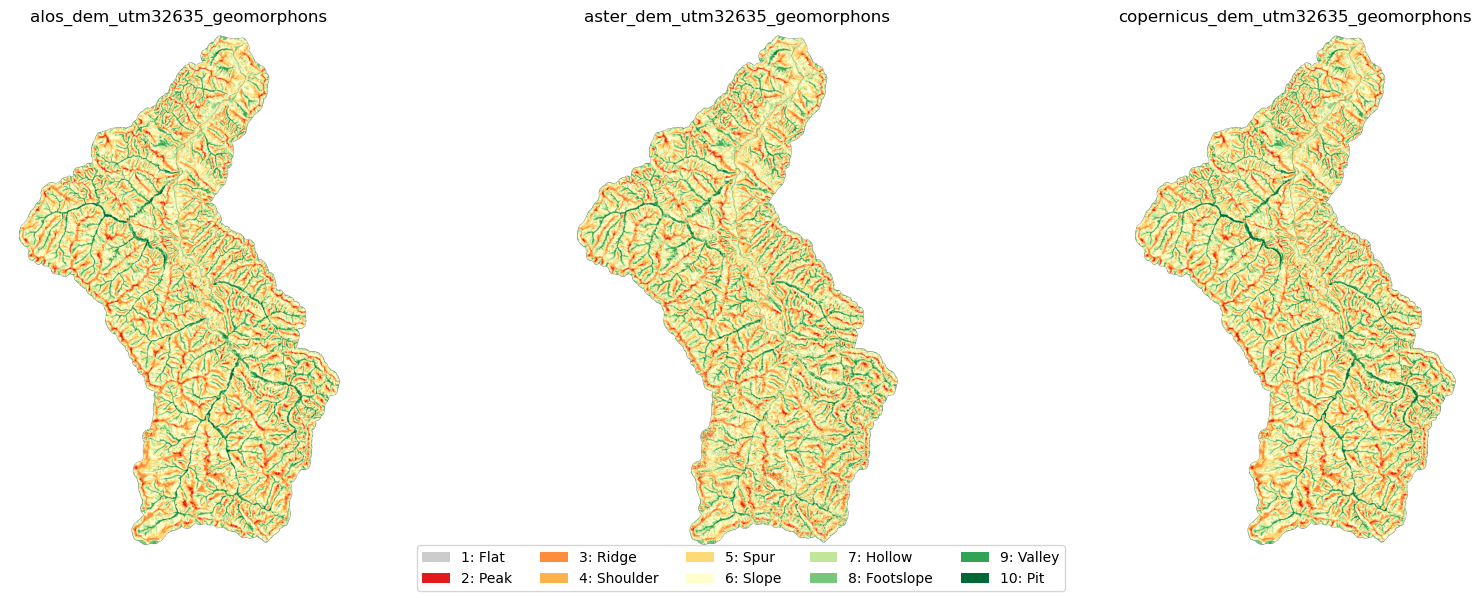

In [2]:
import matplotlib.pyplot as plt
import rasterio
import numpy as np
from pathlib import Path
import matplotlib.colors as mcolors

# 📁 Папка з геоморфонами
geomorphon_folder = Path("/mnt/c/Users/5302/OneDrive/PhD/paper_DEM_artickle/data/DATA_UTM/dem/geomorphons")
geomorphon_files = sorted(geomorphon_folder.glob("*_geomorphons.tif"))

# 🌈 Кольори для форм (1–10)
landform_colors = {
    1: "#cccccc",  # Flat
    2: "#e31a1c",  # Peak
    3: "#fd8d3c",  # Ridge
    4: "#feb24c",  # Shoulder
    5: "#fed976",  # Spur
    6: "#ffffcc",  # Slope
    7: "#c2e699",  # Hollow
    8: "#78c679",  # Footslope
    9: "#31a354",  # Valley
    10: "#006837"  # Pit
}
cmap = mcolors.ListedColormap([landform_colors[i] for i in range(1, 11)])
bounds = np.arange(0.5, 10.6, 1)
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# 📊 Візуалізація перших 3-х DEM
n = min(3, len(geomorphon_files))
fig, axes = plt.subplots(1, n, figsize=(6 * n, 6))

if n == 1:
    axes = [axes]

for ax, file in zip(axes, geomorphon_files[:n]):
    with rasterio.open(file) as src:
        data = src.read(1)
        data = np.where((data >= 1) & (data <= 10), data, np.nan)

    ax.imshow(data, cmap=cmap, norm=norm)
    ax.set_title(file.stem, fontsize=12)
    ax.axis("off")

# 🎨 Додаємо легенду
legend_labels = [
    "1: Flat", "2: Peak", "3: Ridge", "4: Shoulder", "5: Spur",
    "6: Slope", "7: Hollow", "8: Footslope", "9: Valley", "10: Pit"
]
patches = [plt.Rectangle((0,0),1,1,facecolor=landform_colors[i]) for i in range(1, 11)]
fig.legend(patches, legend_labels, loc='lower center', ncol=5, fontsize=10)

plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()
